# Peach Tree Virus Data — Cluster Visualization
**CPSC 4300 Final Project**

This notebook loads, cleans, and visualizes the three-year orchard virus dataset using dimensionality reduction (PCA, t-SNE) and clustering (K-Means) to reveal structure in the data that supports the PLMVd Year 3 prediction task.

## 1. Imports

In [1]:
%pip install pandas numpy matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Consistent aesthetics
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ------------------------- -------------- 5.2/8.1 MB 26.6 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 24.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ------------------------ --------------- 5.0/8.1 MB 25.1 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 22.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   ---------------------- ----------------- 7.1/12.6 MB 33.6 MB/s eta 0:00:01
   ---------------------------------------  12.6/12.6 MB 37.6 MB/s eta 0:00:01
   ---------------------------------------- 12.6/12.6 MB 26.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 26.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/7.0 MB ? eta -:--:--
   ------------------------------


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Load and Clean Data

In [2]:
# --- Load ---
# The CSV has a two-row header: row 0 names the pathogen group,
# row 1 provides the year label. We skip row 0 and assign names manually.
df = pd.read_csv('ThreeYearVirusData.csv', skiprows=1)

df.columns = [
    'Sample_Name', 'Location', 'Cultivar', 'Block', 'Tree_Number', 'Row', 'Tree',
    'PDV_Y1',   'PDV_Y2',   'PDV_Y3',
    'PNRSV_Y1', 'PNRSV_Y2', 'PNRSV_Y3',
    'PLMVd_Y1', 'PLMVd_Y2', 'PLMVd_Y3',
]

print(f"Shape: {df.shape}")
df.head(3)


Shape: (2408, 16)


,Sample_Name,Location,Cultivar,Block,Tree_Number,Row,Tree,PDV_Y1,PDV_Y2,PDV_Y3,PNRSV_Y1,PNRSV_Y2,PNRSV_Y3,PLMVd_Y1,PLMVd_Y2,PLMVd_Y3
0,AP B-1 5351,Edgefield,Augustprince,B-1,5351,1,10,-,-,-,-,-,-,-,-,-
1,AP B-1 5352,Edgefield,Augustprince,B-1,5352,1,9,-,-,-,-,-,-,-,-,-
2,AP B-1 5353,Edgefield,Augustprince,B-1,5353,1,8,-,-,-,-,-,-,-,-,-


In [3]:
# --- Binary-encode the 9 virus test columns (+/- -> 1/0) ---
VIRUS_COLS = [
    'PDV_Y1',   'PDV_Y2',   'PDV_Y3',
    'PNRSV_Y1', 'PNRSV_Y2', 'PNRSV_Y3',
    'PLMVd_Y1', 'PLMVd_Y2', 'PLMVd_Y3',
]
for col in VIRUS_COLS:
    df[col + '_bin'] = (df[col] == '+').astype(int)

# --- Encode Location ---z
le_loc = LabelEncoder()
df['Location_enc'] = le_loc.fit_transform(df['Location'])

# --- Encode Cultivar: top-10 + "Other" ---
top10_cultivars = df['Cultivar'].value_counts().head(10).index.tolist()
df['Cultivar_grp'] = df['Cultivar'].apply(lambda x: x if x in top10_cultivars else 'Other')
le_cult = LabelEncoder()
df['Cultivar_enc'] = le_cult.fit_transform(df['Cultivar_grp'])

# --- Numeric position columns ---
df['Row_num']  = pd.to_numeric(df['Row'],  errors='coerce').fillna(df['Row'].value_counts().index[0])
df['Tree_num'] = pd.to_numeric(df['Tree'], errors='coerce').fillna(0)

print("Missing values:", df.isnull().sum().sum())
print("Class distribution — PLMVd Year 3:")
print(df['PLMVd_Y3_bin'].value_counts().rename({0:'Negative', 1:'Positive'}))


Missing values: 21
Class distribution — PLMVd Year 3:
PLMVd_Y3_bin
Negative    2263
Positive     145
Name: count, dtype: int64


## 3. Build Feature Matrix

In [4]:
# Features used for clustering and dimensionality reduction.
# We include all available prior-year virus data plus metadata.
# PLMVd_Y3_bin is the TARGET — kept in df for coloring but NOT in X.
FEATURE_COLS = [
    'PLMVd_Y1_bin', 'PLMVd_Y2_bin',
    'PDV_Y1_bin',   'PDV_Y2_bin',
    'PNRSV_Y1_bin', 'PNRSV_Y2_bin',
    'Location_enc', 'Cultivar_enc',
    'Row_num', 'Tree_num',
]

X_raw = df[FEATURE_COLS].values
y     = df['PLMVd_Y3_bin'].values  # used only for coloring

# Standardize
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

print(f"Feature matrix: {X.shape}")
print(f"Positive (PLMVd Y3): {y.sum()} / {len(y)}  ({y.mean()*100:.1f}%)")


Feature matrix: (2408, 10)
Positive (PLMVd Y3): 145 / 2408  (6.0%)


## 4. PCA — Explained Variance and 2-D Projection

PCA rotates the feature space to maximize variance along orthogonal axes. We use it to:
1. Inspect how much variance each principal component captures.
2. Project the data to 2-D for visualization, colored by PLMVd Year 3 status.


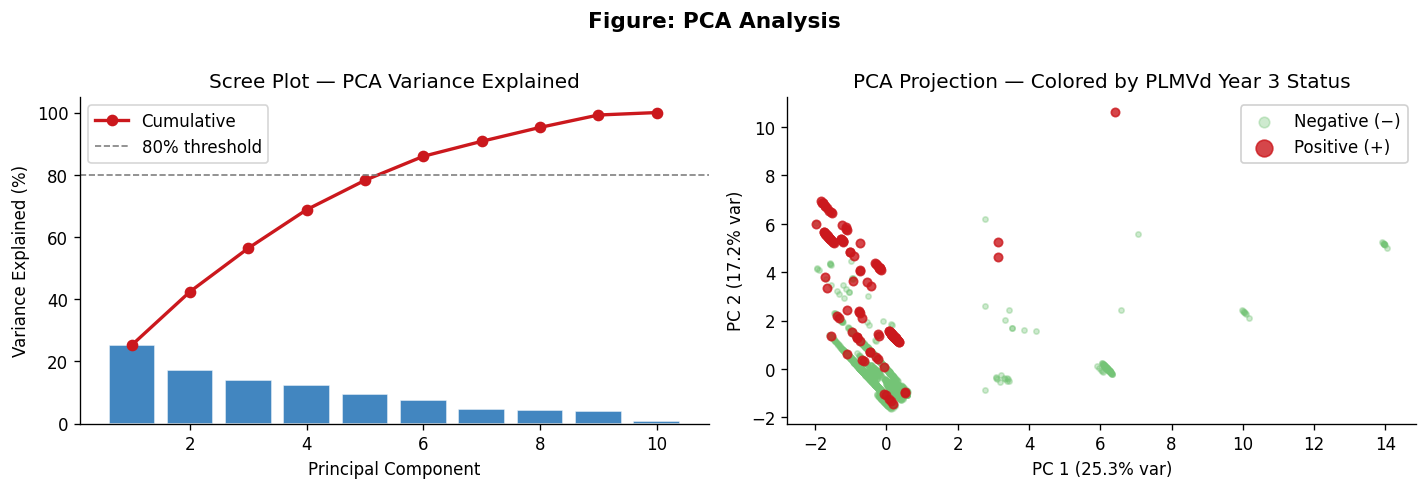

PC1 + PC2 explain 42.5% of variance


In [5]:
pca_full = PCA(n_components=X.shape[1], random_state=42)
pca_full.fit(X)

cumvar = np.cumsum(pca_full.explained_variance_ratio_) * 100
n_components = X.shape[1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Scree plot
axes[0].bar(range(1, n_components+1), pca_full.explained_variance_ratio_*100,
            color='#2171b5', alpha=0.85, edgecolor='white')
axes[0].plot(range(1, n_components+1), cumvar, 'o-', color='#cb181d', linewidth=2, label='Cumulative')
axes[0].axhline(80, color='gray', linestyle='--', linewidth=1, label='80% threshold')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Explained (%)')
axes[0].set_title('Scree Plot — PCA Variance Explained')
axes[0].legend()

# First 2 PCs — colored by PLMVd Y3
pca2 = PCA(n_components=2, random_state=42)
X_pca = pca2.fit_transform(X)

neg_idx = y == 0
pos_idx = y == 1

axes[1].scatter(X_pca[neg_idx, 0], X_pca[neg_idx, 1],
                s=10, alpha=0.35, color='#74c476', label='Negative (−)')
axes[1].scatter(X_pca[pos_idx, 0], X_pca[pos_idx, 1],
                s=25, alpha=0.80, color='#cb181d', label='Positive (+)', zorder=3)
axes[1].set_xlabel(f'PC 1 ({pca_full.explained_variance_ratio_[0]*100:.1f}% var)')
axes[1].set_ylabel(f'PC 2 ({pca_full.explained_variance_ratio_[1]*100:.1f}% var)')
axes[1].set_title('PCA Projection — Colored by PLMVd Year 3 Status')
axes[1].legend(markerscale=2, framealpha=0.9)

plt.suptitle('Figure: PCA Analysis', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_pca.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"PC1 + PC2 explain {cumvar[1]:.1f}% of variance")


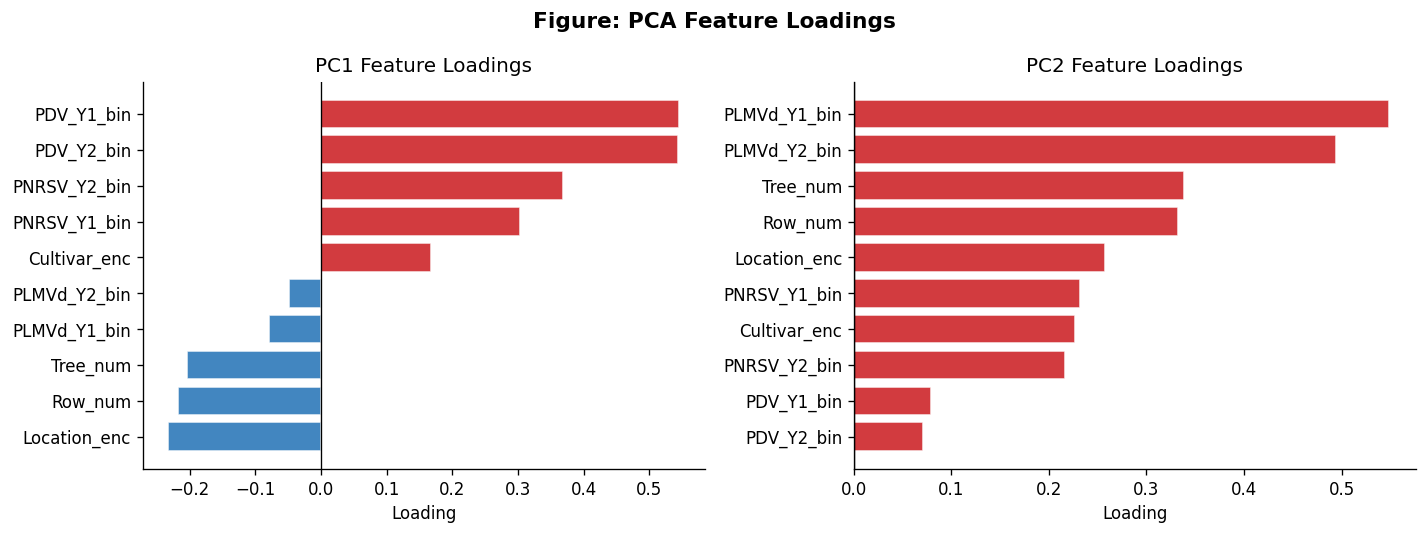

                PC1    PC2
PDV_Y1_bin    0.546  0.079
PDV_Y2_bin    0.543  0.071
PNRSV_Y2_bin  0.368  0.217
PNRSV_Y1_bin  0.303  0.231
Cultivar_enc  0.167  0.226
PLMVd_Y2_bin -0.049  0.495
PLMVd_Y1_bin -0.079  0.549
Tree_num     -0.204  0.338
Row_num      -0.218  0.333
Location_enc -0.233  0.257


In [6]:
# PCA Loadings — what drives each component?
loadings = pd.DataFrame(
    pca2.components_.T,
    index=FEATURE_COLS,
    columns=['PC1', 'PC2']
).sort_values('PC1', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, pc in zip(axes, ['PC1', 'PC2']):
    vals = loadings[pc].sort_values()
    colors = ['#cb181d' if v > 0 else '#2171b5' for v in vals]
    ax.barh(vals.index, vals, color=colors, alpha=0.85, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Loading')
    ax.set_title(f'{pc} Feature Loadings')

plt.suptitle('Figure: PCA Feature Loadings', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_pca_loadings.png', dpi=150, bbox_inches='tight')
plt.show()
print(loadings.round(3).to_string())


## 5. t-SNE — Non-Linear 2-D Projection

t-SNE preserves local neighborhood structure and often reveals clusters that PCA misses. We run it on the full standardized feature matrix and color by PLMVd Year 3 status and by Location.

In [7]:
# t-SNE (perplexity 40 works well for ~2400 samples; can try 20-50)
print("Running t-SNE... (may take ~30 seconds)")
tsne = TSNE(n_components=2, perplexity=40, learning_rate='auto',
            init='pca', random_state=42, n_jobs=-1)
X_tsne = tsne.fit_transform(X)
print("Done.")


Running t-SNE... (may take ~30 seconds)
Done.


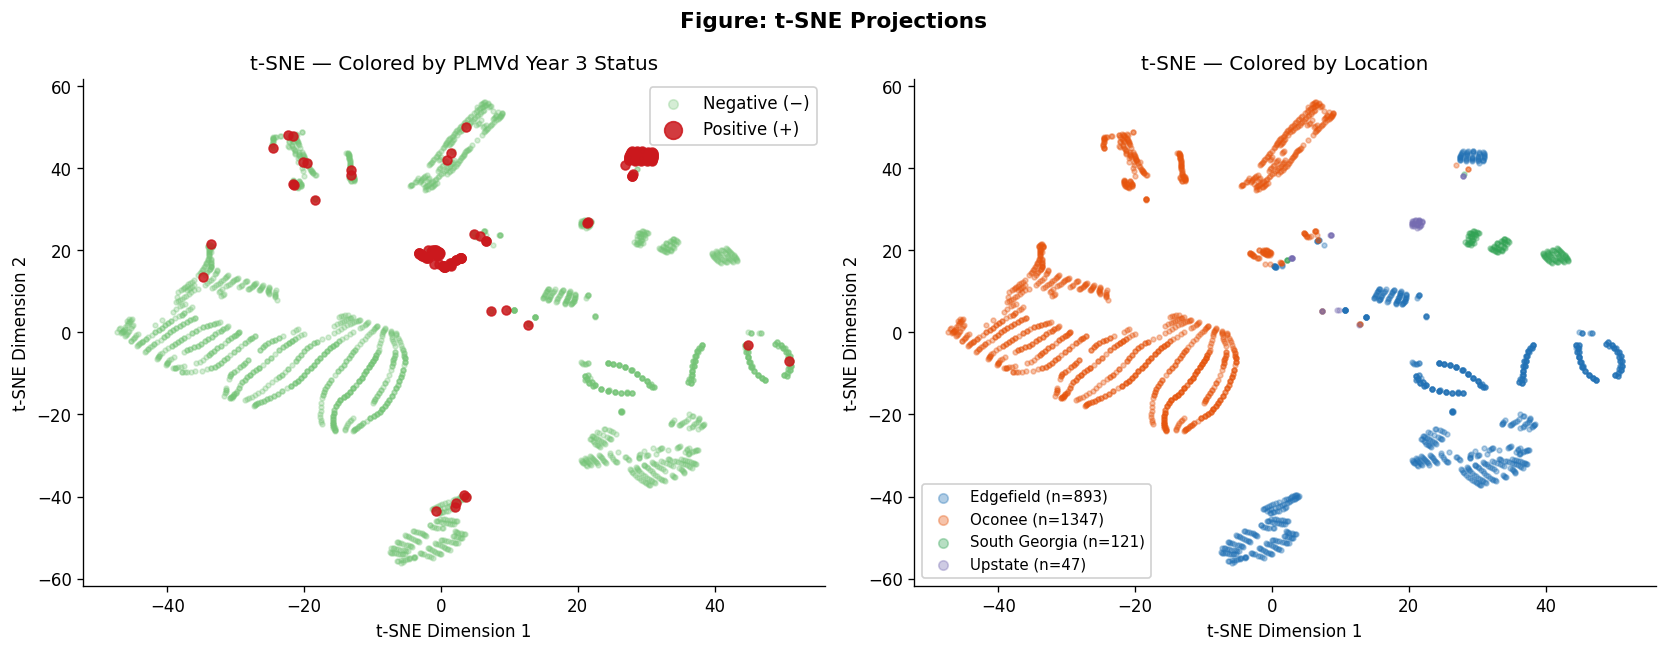

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Left: color by PLMVd Y3 status
axes[0].scatter(X_tsne[neg_idx, 0], X_tsne[neg_idx, 1],
                s=8, alpha=0.30, color='#74c476', label='Negative (−)')
axes[0].scatter(X_tsne[pos_idx, 0], X_tsne[pos_idx, 1],
                s=28, alpha=0.85, color='#cb181d', label='Positive (+)', zorder=3)
axes[0].set_title('t-SNE — Colored by PLMVd Year 3 Status')
axes[0].set_xlabel('t-SNE Dimension 1')
axes[0].set_ylabel('t-SNE Dimension 2')
axes[0].legend(markerscale=2, framealpha=0.9)

# Right: color by Location
loc_colors = {'Edgefield': '#2171b5', 'Oconee': '#e6550d',
               'South Georgia': '#31a354', 'Upstate': '#756bb1'}
for loc, col in loc_colors.items():
    idx = df['Location'] == loc
    axes[1].scatter(X_tsne[idx, 0], X_tsne[idx, 1],
                    s=8, alpha=0.35, color=col, label=f'{loc} (n={idx.sum()})')
axes[1].set_title('t-SNE — Colored by Location')
axes[1].set_xlabel('t-SNE Dimension 1')
axes[1].set_ylabel('t-SNE Dimension 2')
axes[1].legend(markerscale=2, framealpha=0.9, fontsize=9)

plt.suptitle('Figure: t-SNE Projections', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_tsne.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. K-Means Clustering

We use K-Means to group trees into clusters based on their feature profiles, then examine whether clusters differ in PLMVd Year 3 infection rates. First, we select the optimal K using the elbow method and silhouette score.


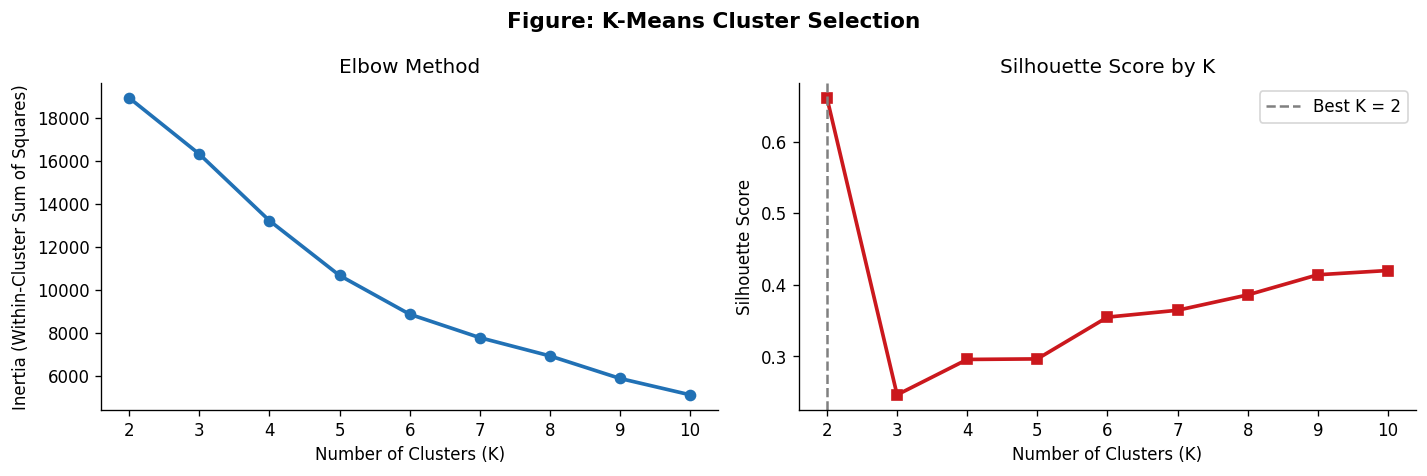

Best K by silhouette: 2


In [9]:
# Elbow + Silhouette to pick K
k_range = range(2, 11)
inertias, silhouettes = [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X, labels, sample_size=1000, random_state=42))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(k_range), inertias, 'o-', color='#2171b5', linewidth=2.2)
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (Within-Cluster Sum of Squares)')
axes[0].set_title('Elbow Method')
axes[0].set_xticks(list(k_range))

axes[1].plot(list(k_range), silhouettes, 's-', color='#cb181d', linewidth=2.2)
best_k = list(k_range)[np.argmax(silhouettes)]
axes[1].axvline(best_k, color='gray', linestyle='--', linewidth=1.5,
                label=f'Best K = {best_k}')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score by K')
axes[1].set_xticks(list(k_range))
axes[1].legend()

plt.suptitle('Figure: K-Means Cluster Selection', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_kmeans_selection.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Best K by silhouette: {best_k}")


In [10]:
# Fit final K-Means with selected K
BEST_K = best_k   # or override manually, e.g. BEST_K = 4

km_final = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
df['Cluster'] = km_final.fit_predict(X)

# Cluster summary table
cluster_summary = df.groupby('Cluster').agg(
    n_trees       = ('PLMVd_Y3_bin', 'count'),
    plmvd_y3_rate = ('PLMVd_Y3_bin', 'mean'),
    plmvd_y1_rate = ('PLMVd_Y1_bin', 'mean'),
    plmvd_y2_rate = ('PLMVd_Y2_bin', 'mean'),
    pdv_y1_rate   = ('PDV_Y1_bin',   'mean'),
).round(3)
cluster_summary['plmvd_y3_pct'] = (cluster_summary['plmvd_y3_rate'] * 100).round(1)
print(cluster_summary.to_string())


         n_trees  plmvd_y3_rate  plmvd_y1_rate  plmvd_y2_rate  pdv_y1_rate  plmvd_y3_pct
Cluster                                                                                 
0           2318          0.062          0.040          0.056        0.001           6.2
1             90          0.011          0.011          0.011        0.978           1.1


C:\Users\ncs44\AppData\Local\Temp\ipykernel_23128\4098535563.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_k = plt.cm.get_cmap('tab10', BEST_K)


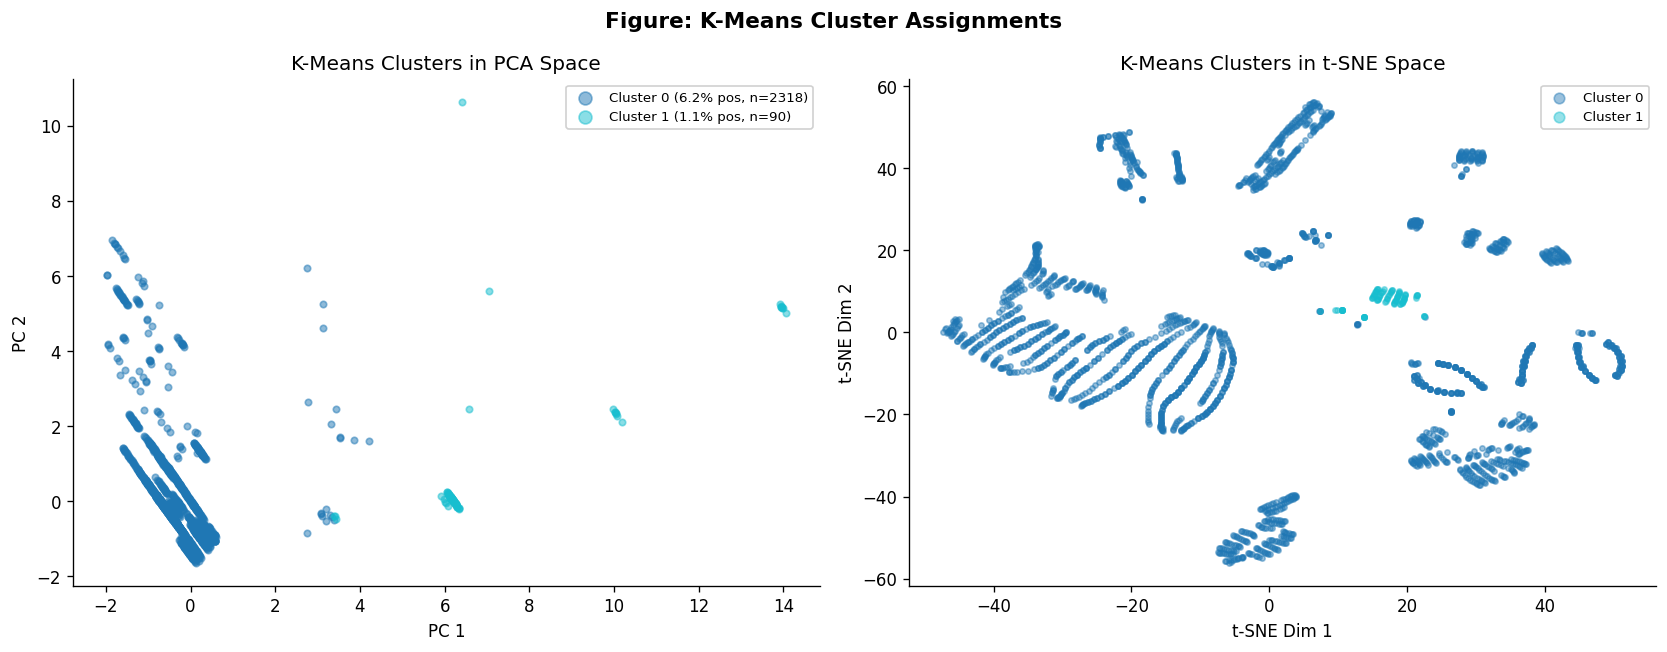

Average silhouette score: 0.661


In [16]:
# Plot clusters in PCA and t-SNE space
cmap_k = plt.cm.get_cmap('tab10', BEST_K)
cluster_colors = [cmap_k(i) for i in range(BEST_K)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for k in range(BEST_K):
    idx_k = df['Cluster'] == k
    rate = cluster_summary.loc[k, 'plmvd_y3_pct']
    axes[0].scatter(X_pca[idx_k, 0], X_pca[idx_k, 1],
                    s=15, alpha=0.5, color=cluster_colors[k],
                    label=f'Cluster {k} ({rate}% pos, n={idx_k.sum()})')
    axes[1].scatter(X_tsne[idx_k, 0], X_tsne[idx_k, 1],
                    s=10, alpha=0.45, color=cluster_colors[k],
                    label=f'Cluster {k}')

for ax, title, xlabel, ylabel in [
    (axes[0], 'K-Means Clusters in PCA Space', 'PC 1', 'PC 2'),
    (axes[1], 'K-Means Clusters in t-SNE Space', 't-SNE Dim 1', 't-SNE Dim 2'),
]:
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8, framealpha=0.9, markerscale=2)

silhouette_avg = silhouette_score(X, df['Cluster'], sample_size=1000, random_state=42)

plt.suptitle('Figure: K-Means Cluster Assignments', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_clusters_projected.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Average silhouette score: {silhouette_avg:.3f}")

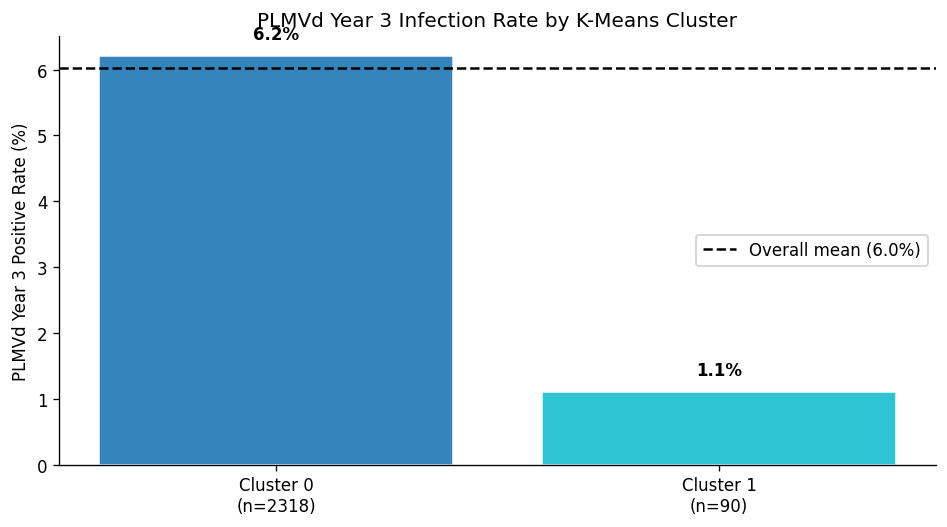

In [12]:
# Bar chart: PLMVd Y3 infection rate by cluster
fig, ax = plt.subplots(figsize=(8, 4.5))
cluster_ids = cluster_summary.index.tolist()
rates = cluster_summary['plmvd_y3_pct'].values
ns    = cluster_summary['n_trees'].values
bar_cols = [cluster_colors[k] for k in cluster_ids]

bars = ax.bar([f'Cluster {k}\n(n={n})' for k, n in zip(cluster_ids, ns)],
              rates, color=bar_cols, edgecolor='white', alpha=0.9)
ax.axhline(df['PLMVd_Y3_bin'].mean()*100, color='black', linestyle='--',
           linewidth=1.5, label=f'Overall mean ({df["PLMVd_Y3_bin"].mean()*100:.1f}%)')
for bar, rate in zip(bars, rates):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
            f'{rate:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('PLMVd Year 3 Positive Rate (%)')
ax.set_title('PLMVd Year 3 Infection Rate by K-Means Cluster')
ax.legend(framealpha=0.9)
plt.tight_layout()
plt.savefig('fig_cluster_infection_rates.png', dpi=150, bbox_inches='tight')
plt.show()


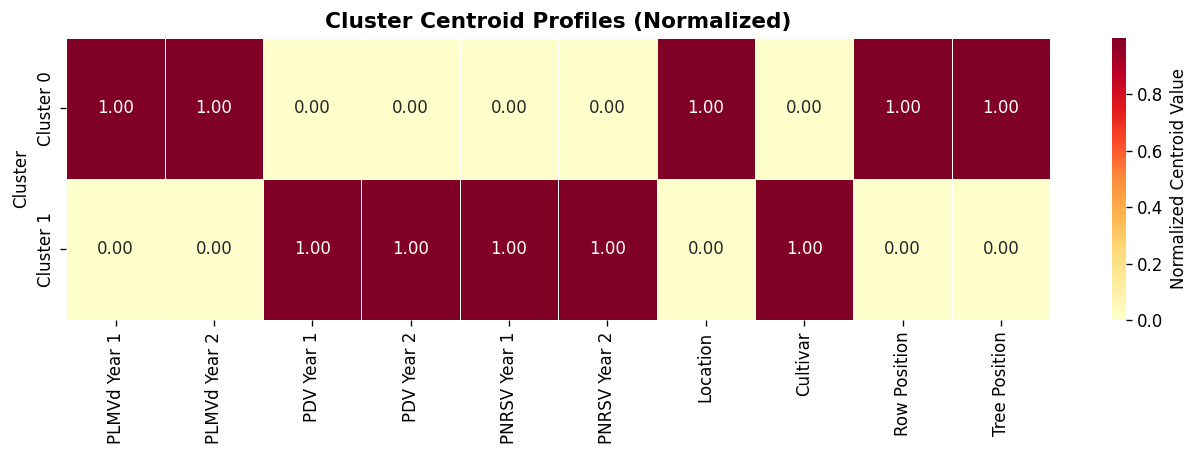

In [13]:
# Heatmap: cluster centroid profiles (original scale, then normalized for display)
centroid_df = pd.DataFrame(
    km_final.cluster_centers_,
    columns=FEATURE_COLS
)
# Normalize each column to [0,1] for readability across different scales
centroid_norm = (centroid_df - centroid_df.min()) / (centroid_df.max() - centroid_df.min() + 1e-9)

# Friendly labels
friendly = {
    'PLMVd_Y1_bin': 'PLMVd Year 1',
    'PLMVd_Y2_bin': 'PLMVd Year 2',
    'PDV_Y1_bin':   'PDV Year 1',
    'PDV_Y2_bin':   'PDV Year 2',
    'PNRSV_Y1_bin': 'PNRSV Year 1',
    'PNRSV_Y2_bin': 'PNRSV Year 2',
    'Location_enc': 'Location',
    'Cultivar_enc': 'Cultivar',
    'Row_num':      'Row Position',
    'Tree_num':     'Tree Position',
}
centroid_norm.columns = [friendly[c] for c in FEATURE_COLS]
centroid_norm.index = [f'Cluster {k}' for k in range(BEST_K)]

fig, ax = plt.subplots(figsize=(11, 1.2 * BEST_K + 1.5))
sns.heatmap(centroid_norm, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Normalized Centroid Value'})
ax.set_title('Cluster Centroid Profiles (Normalized)', fontsize=13, fontweight='bold')
ax.set_ylabel('Cluster')
plt.tight_layout()
plt.savefig('fig_cluster_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. PCA Biplot with Cluster Overlay

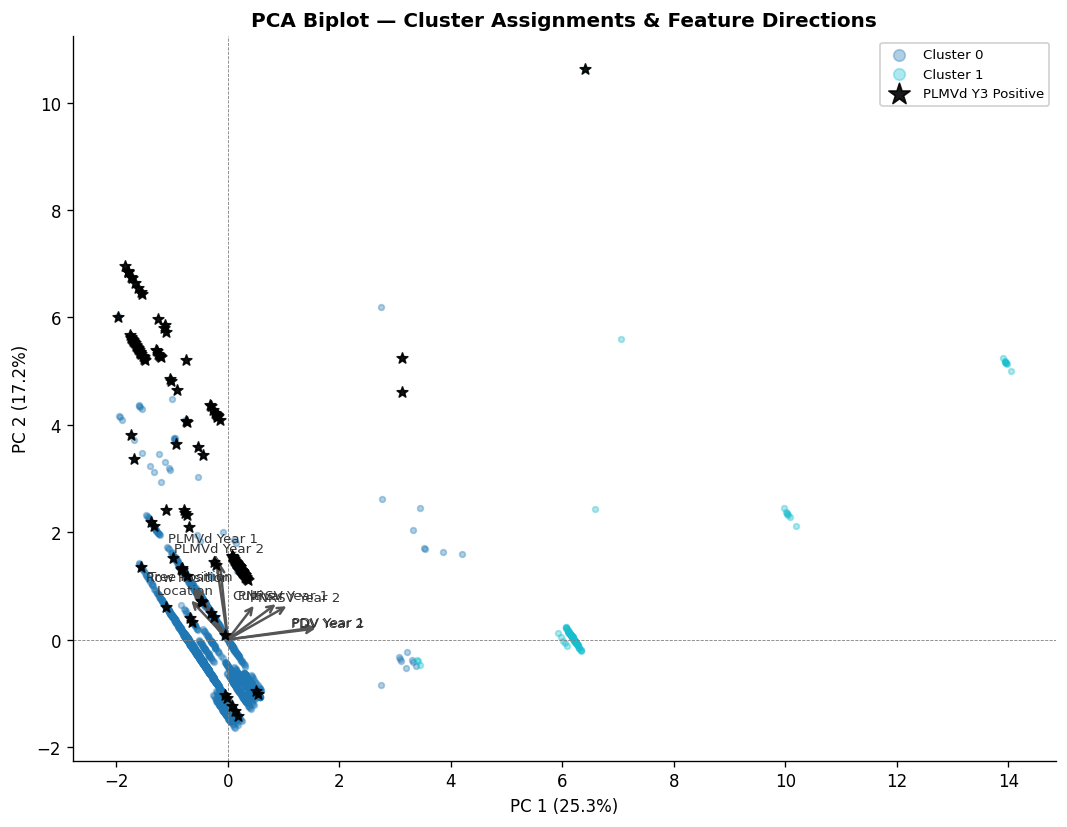

In [14]:
# Biplot: show both data points and feature direction arrows
fig, ax = plt.subplots(figsize=(9, 7))

for k in range(BEST_K):
    idx_k = df['Cluster'] == k
    ax.scatter(X_pca[idx_k, 0], X_pca[idx_k, 1],
               s=12, alpha=0.35, color=cluster_colors[k], label=f'Cluster {k}')

# Overlay positive trees on top
ax.scatter(X_pca[pos_idx, 0], X_pca[pos_idx, 1],
           s=45, alpha=0.9, color='black', marker='*',
           label='PLMVd Y3 Positive', zorder=5)

# Feature arrows (scaled for visibility)
scale = 3.0
for i, feat in enumerate(FEATURE_COLS):
    ax.annotate('', xy=(pca2.components_[0, i]*scale, pca2.components_[1, i]*scale),
                xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='#555555', lw=1.5))
    ax.text(pca2.components_[0, i]*scale*1.1, pca2.components_[1, i]*scale*1.1,
            friendly[feat], fontsize=8, color='#333333', ha='center')

ax.set_xlabel(f'PC 1 ({pca_full.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC 2 ({pca_full.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('PCA Biplot — Cluster Assignments & Feature Directions', fontsize=12, fontweight='bold')
ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax.axvline(0, color='gray', linewidth=0.5, linestyle='--')
ax.legend(fontsize=8, markerscale=2, framealpha=0.9)
plt.tight_layout()
plt.savefig('fig_biplot.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. DBSCAN

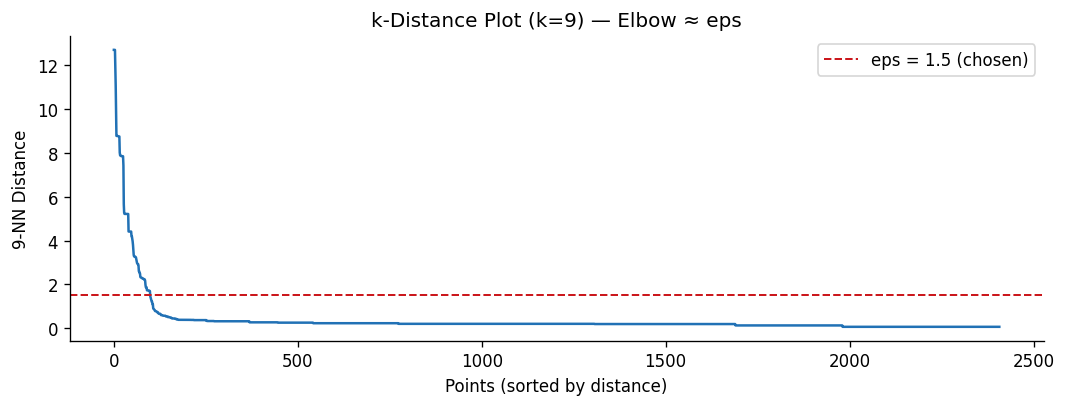

DBSCAN found 10 cluster(s) and 97 noise points (4.0%)
label
 8    910
 0    724
 6    364
 2    117
-1     97
 5     69
 3     52
 1     29
 9     24
 7     12
 4     10


In [18]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

# --- Step 1: k-distance plot to choose eps ---
# For each point, find distance to its k-th nearest neighbor (k = min_samples - 1).
# The "elbow" in the sorted distances is a good eps candidate.
MIN_SAMPLES = 10
k = MIN_SAMPLES - 1

nbrs = NearestNeighbors(n_neighbors=k).fit(X)
distances, _ = nbrs.kneighbors(X)
k_dists = np.sort(distances[:, -1])[::-1]  # sorted descending

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(k_dists, color='#2171b5', linewidth=1.5)
ax.set_xlabel('Points (sorted by distance)')
ax.set_ylabel(f'{k}-NN Distance')
ax.set_title(f'k-Distance Plot (k={k}) — Elbow ≈ eps')
# Highlight a reasonable elbow region
ax.axhline(1.5, color='#cb181d', linestyle='--', linewidth=1.2, label='eps = 1.5 (chosen)')
ax.legend()
plt.tight_layout()
plt.savefig('fig_dbscan_kdist.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Step 2: Fit DBSCAN ---
EPS = 1.5
dbscan = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES)
db_labels = dbscan.fit_predict(X)
df['DBSCAN_Cluster'] = db_labels

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise    = (db_labels == -1).sum()
print(f"DBSCAN found {n_clusters} cluster(s) and {n_noise} noise points "
      f"({n_noise/len(db_labels)*100:.1f}%)")
print(pd.Series(db_labels).value_counts().rename('count').rename_axis('label').to_string())


C:\Users\ncs44\AppData\Local\Temp\ipykernel_23128\1193606680.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_db = plt.cm.get_cmap('tab10', max(n_clusters, 1))


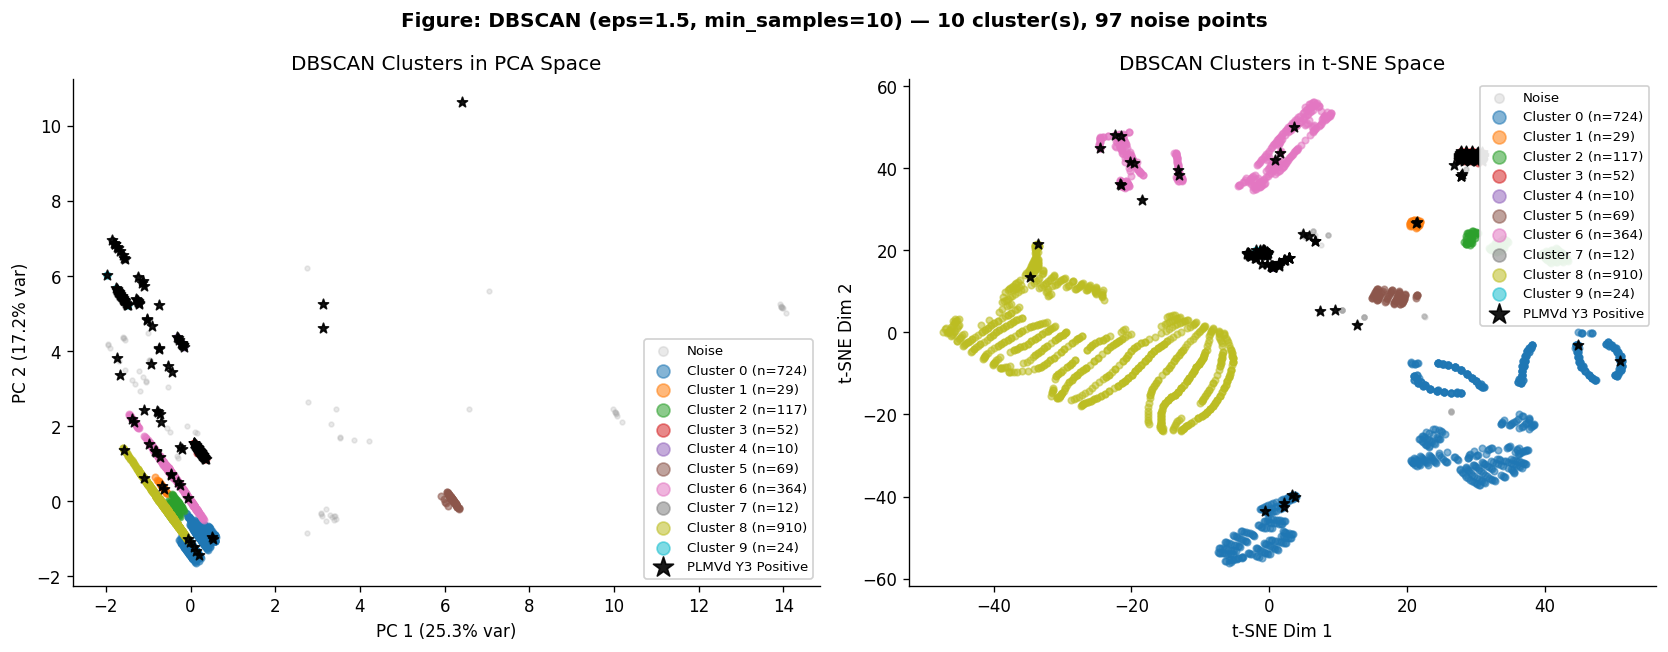

In [19]:
# --- Step 3: Visualize DBSCAN in PCA and t-SNE space ---
unique_labels = sorted(set(db_labels))
cmap_db = plt.cm.get_cmap('tab10', max(n_clusters, 1))

def db_color(label):
    return '#aaaaaa' if label == -1 else cmap_db(label)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for label in unique_labels:
    idx_l = db_labels == label
    name  = 'Noise' if label == -1 else f'Cluster {label} (n={idx_l.sum()})'
    col   = db_color(label)
    size  = 8 if label == -1 else 15
    alpha = 0.25 if label == -1 else 0.55
    axes[0].scatter(X_pca[idx_l, 0], X_pca[idx_l, 1],
                    s=size, alpha=alpha, color=col, label=name)
    axes[1].scatter(X_tsne[idx_l, 0], X_tsne[idx_l, 1],
                    s=size, alpha=alpha, color=col, label=name)

# Overlay PLMVd Y3 positive trees
for ax in axes:
    ax.scatter(X_pca[pos_idx, 0] if ax is axes[0] else X_tsne[pos_idx, 0],
               X_pca[pos_idx, 1] if ax is axes[0] else X_tsne[pos_idx, 1],
               s=40, alpha=0.9, color='black', marker='*',
               label='PLMVd Y3 Positive', zorder=5)

axes[0].set_title('DBSCAN Clusters in PCA Space')
axes[0].set_xlabel(f'PC 1 ({pca_full.explained_variance_ratio_[0]*100:.1f}% var)')
axes[0].set_ylabel(f'PC 2 ({pca_full.explained_variance_ratio_[1]*100:.1f}% var)')
axes[0].legend(fontsize=8, framealpha=0.9, markerscale=2)

axes[1].set_title('DBSCAN Clusters in t-SNE Space')
axes[1].set_xlabel('t-SNE Dim 1')
axes[1].set_ylabel('t-SNE Dim 2')
axes[1].legend(fontsize=8, framealpha=0.9, markerscale=2)

plt.suptitle(f'Figure: DBSCAN (eps={EPS}, min_samples={MIN_SAMPLES}) — '
             f'{n_clusters} cluster(s), {n_noise} noise points',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_dbscan_projected.png', dpi=150, bbox_inches='tight')
plt.show()


       n_trees  plmvd_y3_rate  plmvd_y3_pct
label                                      
-1          97          0.299          29.9
 0         724          0.010           1.0
 1          29          0.069           6.9
 2         117          0.000           0.0
 3          52          0.923          92.3
 4          10          1.000         100.0
 5          69          0.000           0.0
 6         364          0.033           3.3
 7          12          1.000         100.0
 8         910          0.002           0.2
 9          24          0.958          95.8


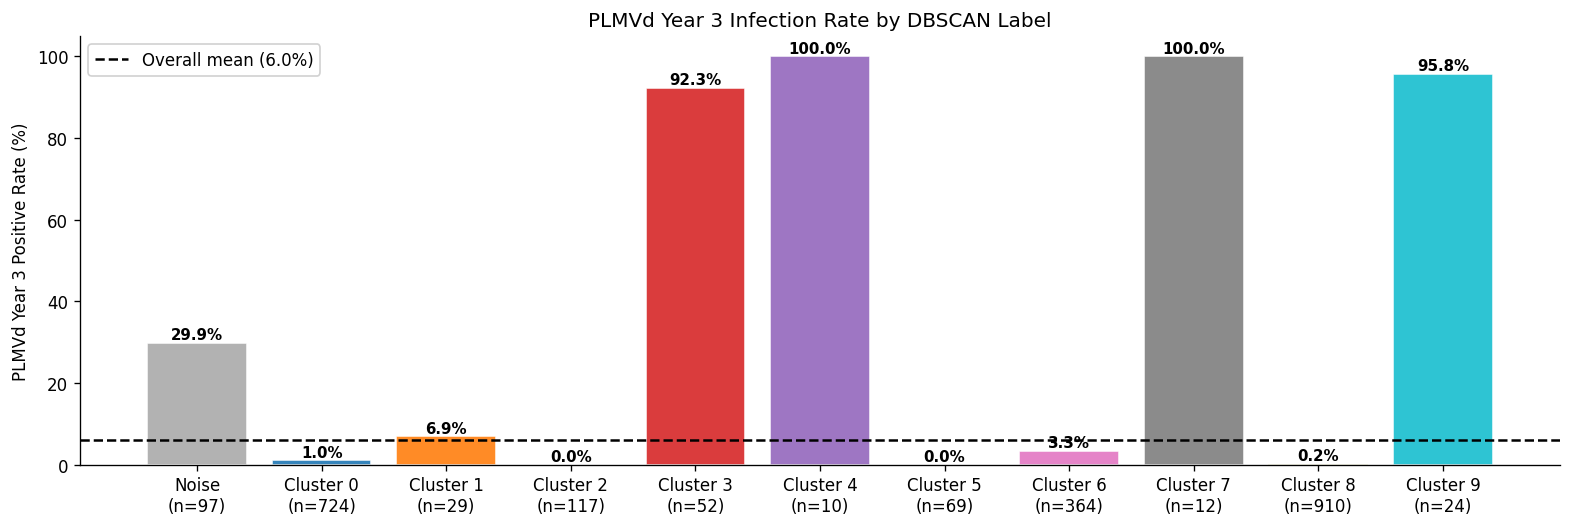

In [20]:
# --- Step 4: PLMVd Y3 infection rate by DBSCAN label ---
db_summary = df.groupby('DBSCAN_Cluster').agg(
    n_trees       = ('PLMVd_Y3_bin', 'count'),
    plmvd_y3_rate = ('PLMVd_Y3_bin', 'mean'),
).round(3)
db_summary['plmvd_y3_pct'] = (db_summary['plmvd_y3_rate'] * 100).round(1)
db_summary.index.name = 'label'
print(db_summary.to_string())

fig, ax = plt.subplots(figsize=(max(6, len(db_summary) * 1.2), 4.5))
labels_sorted = db_summary.index.tolist()
rates = db_summary['plmvd_y3_pct'].values
ns    = db_summary['n_trees'].values
bar_cols = [db_color(l) for l in labels_sorted]
tick_labels = ['Noise' if l == -1 else f'Cluster {l}' for l in labels_sorted]
tick_labels = [f'{t}\n(n={n})' for t, n in zip(tick_labels, ns)]

bars = ax.bar(tick_labels, rates, color=bar_cols, edgecolor='white', alpha=0.9)
ax.axhline(df['PLMVd_Y3_bin'].mean()*100, color='black', linestyle='--',
           linewidth=1.5, label=f'Overall mean ({df["PLMVd_Y3_bin"].mean()*100:.1f}%)')
for bar, rate in zip(bars, rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{rate:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_ylabel('PLMVd Year 3 Positive Rate (%)')
ax.set_title('PLMVd Year 3 Infection Rate by DBSCAN Label')
ax.legend(framealpha=0.9)
plt.tight_layout()
plt.savefig('fig_dbscan_infection_rates.png', dpi=150, bbox_inches='tight')
plt.show()
